<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/30_Experimental_Design_in_Python/02_Experimental_Design_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt


In [18]:

import pandas as pd

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/marketing_data.feather"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
marketing_data = pd.read_feather(url)
display(marketing_data.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/chick_weight.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
chick_weight = pd.read_csv(url)
display(chick_weight.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/ad_conversion.csv"
# Read the CSV file
ad_conversion = pd.read_csv(url)
display(ad_conversion.head())

,Messaging_Style,Time_of_Day,Click_Through_Rate,Conversions
0,Casual,Morning,0.640465,500
1,Formal,Evening,0.698533,598
2,Casual,Morning,0.257834,234
3,Casual,Evening,0.922971,602
4,Casual,Morning,0.476893,314


,weight,Time,Chick,Diet
0,42,0,1,1
1,51,2,1,1
2,59,4,1,1
3,64,6,1,1
4,76,8,1,1


,spent_usd,n_impressions,n_clicks
0,1.43,7350,1
1,1.82,17861,2
2,1.25,4259,1
3,1.29,4133,1
4,4.77,15615,3


**Understanding marketing campaign effectiveness**  
Imagine you're a digital marketer analyzing data from a recent campaign to understand what messaging style and time of day yield the highest conversions. This analysis is crucial for guiding future marketing strategies, ensuring that your messages reach potential customers when they're most likely to engage. In this exercise, you're working with a dataset giving the outcomes of different messaging styles ('Casual' versus 'Formal') and times of day ('Morning' versus 'Evening') on conversion rates, a common scenario in marketing data analysis.

The data has been loaded for you as a DataFrame named marketing_data, and pandas is loaded as pd.

In [19]:
# Create a pivot table for marketing campaign data
marketing_pivot = marketing_data.pivot_table(
  values='Conversions',
  index='Messaging_Style',
  columns='Time_of_Day',
  aggfunc='mean')

# View the pivoted results
print(marketing_pivot)

# Notice that the mean conversion is highest for the 'Formal' messaging style in the 'Evening' time of day.

Time_of_Day         Evening     Morning
Messaging_Style                        
Casual           402.329004  401.133891
Formal           432.913043  411.096000


**Heatmap of campaign interactions**  
Visualizing data can often reveal patterns that are not immediately obvious. In the context of marketing, understanding how different factors interact and affect the success of a campaign is vital. By creating a heatmap of conversions based on messaging style and time of day, you can quickly identify which combinations perform best and which ones need reevaluation. This visual tool is invaluable for marketing teams looking to optimize their strategies for maximum impact.

The data from the previous exercise has been loaded for you as marketing_pivot, seaborn is loaded as sns, and matplotlib.pyplot as plt.

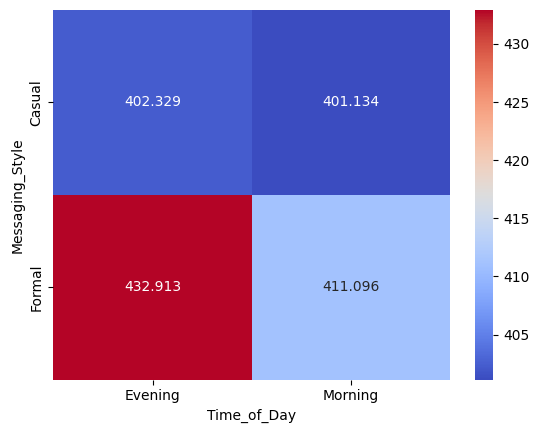

In [20]:
# Visualize interactions with a heatmap
sns.heatmap(marketing_pivot,
            annot=True,
            cmap='coolwarm',
            fmt='g')

plt.show()

# ? Where was the most pronounced change in conversions? -> From 'Formal' to 'Casual' in 'Evening' time

# The difference of 432.913 to 402.329 is the most pronounced change in conversions.

**Factorial designs and randomized block designs**  
Select the three correct statements regarding factorial designs and randomized block designs.

-> - Factorial designs require each experimental unit to be exposed to all possible combinations of treatment levels


- Randomized block designs enhance experimental precision by controlling for variability within groups of similar subjects

- Factorial designs are particularly useful in complex scenarios with multiple factors influencing the outcome

### Implementing a randomized block design
The manufacturing firm you worked with earlier is still interested in conducting some experiments on worker productivity. Previously, the two blocks were set randomly. While this can work, it can be better to group subjects based on similar characteristics.

The same employees are again loaded but this time in a DataFrame called productivity including 1200 other colleagues. It also includes a worker 'productivity_score' column based on units produced per hour. This column was binned into three groups to generate blocks based on similar productivity values. The firm would like to apply a new incentive program with three options ('Bonus', 'Profit Sharing' and 'Work from Home') throughout the firm with treatment applied randomly.

numpy and pandas as np and pd respectively are loaded.

In [21]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/productivity.csv"
# Read the CSV file
productivity = pd.read_csv(url)
display(productivity.head())

# Randomly assign workers to blocks
prod_df = productivity.groupby('block').apply(
  lambda x: x.sample(frac=1)
)

# Reset the index
prod_df = prod_df.reset_index(drop=True)

# Assign treatment randomly
prod_df['Treatment'] = np.random.choice(
  ['Bonus', 'Profit Sharing', 'Work from Home'],
  size=len(prod_df)
)

# You've efficiently shuffled workers within their blocks, streamlined the DataFrame
# by resetting the index, and randomly assigned treatments, setting a solid foundation for a
# nalyzing incentive effects on productivity. Your skills in preparing data for experimental analysis are on point!

,subject_id,productivity_score,block
0,1,11.9,2.0
1,2,28.6,3.0
2,3,22.2,3.0
3,4,18.4,2.0
4,5,5.5,1.0


/tmp/ipython-input-21-1172914848.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prod_df = productivity.groupby('block').apply(


**Visualizing productivity within blocks by incentive**  
Continuing with the worker productivity example, you'll explore if the productivity scores are distributed throughout the data as one would expect with random assignment of treatment. Note that this is a precautionary step, and the treatment and follow-up results on the impact of the three treatments is not done yet!

seaborn and matplotlib.pyplot as sns and plt respectively are loaded.

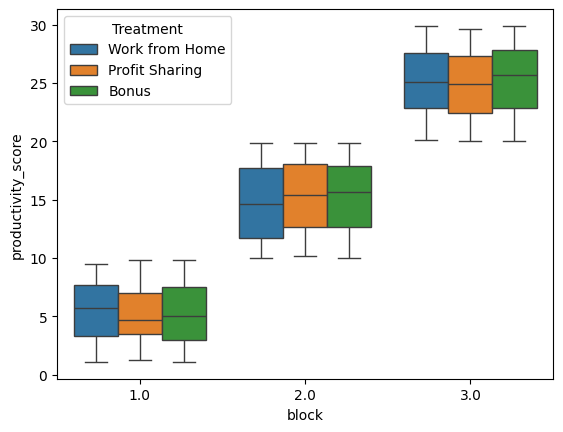

In [22]:
# Make a plot showing how positivity_score varies within blocks
sns.boxplot (x='block',
            y='productivity_score',
            hue='Treatment',
            data=prod_df)

plt.show()

  **ANOVA within blocks of employees**  
Building on your previous analyses with the manufacturing firm, where worker productivity was examined across different blocks and an incentive program was introduced, you're now delving deeper into the data. The firm, equipped with a more comprehensive dataset in the productivity DataFrame, including 1200 additional employees and their productivity_score, has structured the workforce into three blocks based on productivity levels. Each employee has been randomly assigned one of three incentive options: 'Bonus', 'Profit Sharing', or 'Work from Home'.

Before assessing the full impact of these incentive treatments on productivity, it's crucial to verify that the initial treatment assignment was indeed random and equitable across the different productivity blocks. This step ensures that any observed differences in productivity post-treatment can be confidently attributed to the incentive programs themselves, rather than pre-existing disparities in the blocks.

The f_oneway() function from scipy.stats has been loaded for you.

In [24]:
from scipy.stats import f_oneway

# Perform the within blocks ANOVA, first grouping by block
within_block_anova = prod_df.groupby('block').apply(
  lambda x: f_oneway(
    x[x['Treatment'] == 'Bonus']['productivity_score'],
    x[x['Treatment'] == 'Profit Sharing']['productivity_score'],
    x[x['Treatment'] == 'Work from Home']['productivity_score'])
)
print(within_block_anova)

# You've adeptly conducted an ANOVA analysis across the different blocks, comparing
# the productivity scores for the three treatment groups. Notice that each of the three
# p-values are large, so you can feel confident in how this randomized block design is set up as an experiment.

block
1.0    (0.5666681721586937, 0.5678533508193413)
2.0    (1.923027138880864, 0.14739869599701536)
3.0    (0.8018781109138255, 0.4491401646094402)
dtype: object


### Covariate adjustment with chick growth
Imagine studying in agricultural science the growth patterns of chicks under various dietary regimens. The data from this study sheds light on the intricate relationship between their respective diets and the consequent impact on their weight. This data includes weight measurements of chicks at different ages, allowing for an exploration of covariate adjustment. age serves as a covariate, potentially influencing the outcome variable: the weight of the chicks.

DataFrames exp_chick_data, the experimental data, and cov_chick_data, the covariate data, have been loaded, along with the following libraries:

    import pandas as pd
    import numpy as np
    from statsmodels.formula.api import ols
    import seaborn as sns
    import matplotlib.pyplot as plt


                            OLS Regression Results                            
Dep. Variable:               weight_x   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     9562.
Date:                Sat, 12 Jul 2025   Prob (F-statistic):               0.00
Time:                        17:51:55   Log-Likelihood:                -34190.
No. Observations:                6818   AIC:                         6.839e+04
Df Residuals:                    6815   BIC:                         6.841e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4349      1.190      1.206      0.2

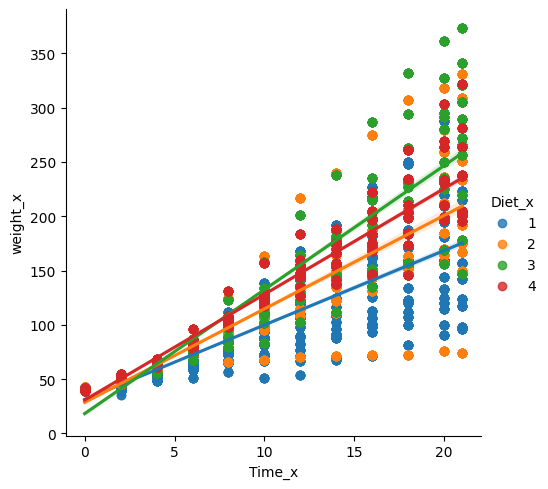

In [25]:
# Join experimental and covariate data
merged_chick_data = pd.merge(exp_chick_data,
                             cov_chick_data, on='Chick')

# Perform ANCOVA with Diet and Time as predictors
from statsmodels.formula.api import ols
model = ols('weight_x ~ Diet_x + Time_x', data=merged_chick_data).fit()

# Print a summary of the model
print(model.summary())

# Visualize Diet effects with Time adjustment
sns.lmplot(x='Time_x', y='weight_x', hue='Diet_x', data=merged_chick_data)

# You've successfully merged the experimental and covariate data to create a
# comprehensive dataset, then adeptly performed an ANCOVA, incorporating both
# 'Diet' and 'Time' as predictors. The visualization further clarifies how diet
# influences weight over time. It looks like 'Time' might not be as meaningful
# since the lines are all close to parallel, and the large p-value in the summary
# also corresponds to the 'Time' coefficient!

In [26]:
# Load the experimental and covariate chick data
url_exp = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/chick_weight.csv"
exp_chick_data = pd.read_csv(url_exp)

# For the covariate data, we can use the same chick_weight data, but perhaps subsetted or modified if the context implies a different structure.
# Assuming for now that cov_chick_data is also derived from chick_weight,
# let's create a simplified version for demonstration, perhaps focusing on initial weight as a covariate.
# If cov_chick_data is meant to be a different dataset, please provide the correct URL.

# For this example, let's assume cov_chick_data is the same as exp_chick_data for simplicity.
# If there is a specific covariate dataset, the URL would need to be updated.
cov_chick_data = exp_chick_data.copy()

display(exp_chick_data.head())
display(cov_chick_data.head())

,weight,Time,Chick,Diet
0,42,0,1,1
1,51,2,1,1
2,59,4,1,1
3,64,6,1,1
4,76,8,1,1


,weight,Time,Chick,Diet
0,42,0,1,1
1,51,2,1,1
2,59,4,1,1
3,64,6,1,1
4,76,8,1,1
